In [15]:
# 1️⃣ Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [17]:
# 3️⃣ Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [18]:
# 4️⃣ Load datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_path, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")


Classes: ['Fake', 'Real']
Train samples: 140002, Validation samples: 39428, Test samples: 10905


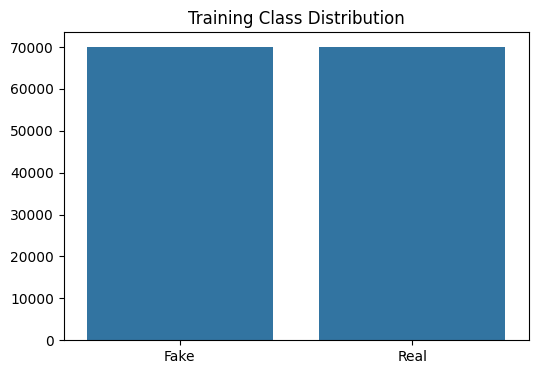

In [19]:
# 5️⃣ Class distribution visualization
train_counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in class_names]
plt.figure(figsize=(6,4))
sns.barplot(x=class_names, y=train_counts)
plt.title("Training Class Distribution")
plt.show()

In [20]:
# 6️⃣ Model: EfficientNet-B0 Transfer Learning
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 2)
)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


In [ ]:
from tqdm import tqdm  # progress bar

def train_model(model, epochs=5):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_acc = 0.0
    
    # Make sure model is on GPU
    model = model.to(device)
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        # -------- Training --------
        model.train()
        running_loss, correct = 0.0, 0
        
        for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels)
        
        train_loss = running_loss / len(train_dataset)
        train_acc = correct.double() / len(train_dataset)
        train_losses.append(train_loss)
        train_accs.append(train_acc.cpu().numpy())
        
        # -------- Validation --------
        model.eval()
        val_loss, val_correct = 0.0, 0
        all_preds, all_labels, all_probs = [], [], []
        
        with torch.no_grad():  # ensure no gradients in validation
            for inputs, labels in tqdm(val_loader, desc="Validation", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                
                val_correct += torch.sum(preds == labels)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs[:,1].detach().cpu().numpy())  
        
        val_loss /= len(val_dataset)
        val_acc = val_correct.double() / len(val_dataset)
        val_losses.append(val_loss)
        val_accs.append(val_acc.cpu().numpy())
        
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "/kaggle/working/best_deepfake_model.pth")
            print("🔥 Best model saved!")
    
    return train_losses, val_losses, train_accs, val_accs, all_labels, all_preds, all_probs

In [35]:
train_losses, val_losses, train_accs, val_accs, labels, preds, probs = train_model(model, epochs=5)


Epoch 1/5


Train Acc: 0.8433 | Val Acc: 0.8136
🔥 Best model saved!

Epoch 2/5


Train Acc: 0.8488 | Val Acc: 0.8143
🔥 Best model saved!

Epoch 3/5


Train Acc: 0.8518 | Val Acc: 0.8142

Epoch 4/5


Train Acc: 0.8576 | Val Acc: 0.8160
🔥 Best model saved!

Epoch 5/5


Train Acc: 0.8575 | Val Acc: 0.8273
🔥 Best model saved!
